# Trading Strategies with Token Metrics AI API

This notebook demonstrates how to implement trading strategies using the data from Token Metrics AI API. We'll implement two strategies:

1. **ETH Breakout Strategy** - A strategy that buys ETH when it breaks above its 30-day high
2. **Market Cap Weighted Portfolio** - A strategy that builds a portfolio of the top 10 tokens by market cap

Note: For backtesting, we'll use VectorBT, a powerful library for backtesting trading strategies.

## Setup

Let's install the required packages:

In [ ]:
# Uncomment to install packages
# !pip install tmai-api pandas vectorbt matplotlib

Import the necessary libraries:

In [2]:
from tmai_api import TokenMetricsClient
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Set Matplotlib parameters
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 8)

# Initialize the client
client = TokenMetricsClient(api_key="tm-b7212f8d-1bcb-4c40-be3f-b4d1a4eeee72")

## Strategy 1: ETH Breakout Strategy

This strategy buys ETH when it breaks above its 30-day high and sells after 3 days.

### Step 1: Fetch ETH Daily Price Data

We'll use the `daily_ohlcv` endpoint to get Ethereum's price data for the last year.

In [6]:
# Calculate date range for the last year
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=1600)).strftime("%Y-%m-%d")

# Fetch ETH daily OHLCV data
# Using token_id=3306 for Ethereum as recommended in the strategy
eth_ohlcv_df = client.daily_ohlcv.get_dataframe(
    token_id="3306",
    startDate=start_date,
    endDate=end_date
)

# Display the data
eth_ohlcv_df.head()

Fetching daily-ohlcv data: 100%|██████████| 56/56 [00:19<00:00,  2.82chunk/s]


,TOKEN_ID,TOKEN_NAME,TOKEN_SYMBOL,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME
0,3306,Ethereum,ETH,2020-12-08T00:00:00.000Z,590.819535,595.71,542.46,554.659620,1.145123e+08
1,3306,Ethereum,ETH,2020-12-07T00:00:00.000Z,600.776284,603.80,580.18,591.087584,2.136932e+07
2,3306,Ethereum,ETH,2020-12-06T00:00:00.000Z,597.243433,607.64,580.92,601.107085,6.101004e+07
3,3306,Ethereum,ETH,2020-12-05T00:00:00.000Z,571.316667,598.00,559.24,596.182698,2.548545e+07
4,3306,Ethereum,ETH,2020-12-04T00:00:00.000Z,615.434349,620.92,564.24,568.396107,5.644876e+07


### Step 2: Prepare Data for the Strategy

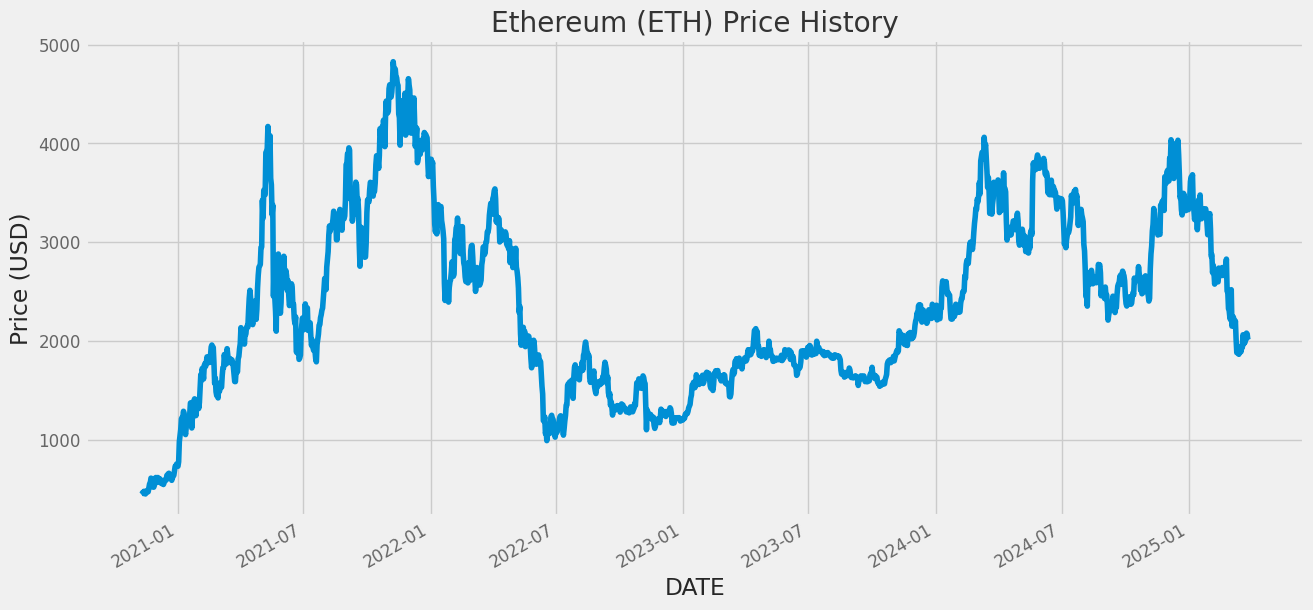

In [7]:
# Filter for Ethereum data only and sort by date
eth_data = eth_ohlcv_df[eth_ohlcv_df['TOKEN_ID'] == 3306].copy()
eth_data['DATE'] = pd.to_datetime(eth_data['DATE'])
eth_data = eth_data.sort_values('DATE')

# Extract closing price and set index to timestamp
eth_price = eth_data.set_index('DATE')['CLOSE']

# Plot ETH price
plt.figure(figsize=(14, 7))
eth_price.plot(title="Ethereum (ETH) Price History")
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

### Step 3: Implement the ETH Breakout Strategy

In [8]:
# Compute 30-day high (shifted by 1 day to avoid look-ahead bias)
rollmax = eth_price.rolling(30).max().shift(1)

# Define entry signals: price breaks above 30-day high
entries = eth_price > rollmax

# Define exit signals: sell 3 days after entry
exits = entries.shift(3).fillna(False)

# Display first few signals
pd.DataFrame({
    'Price': eth_price,
    '30-Day High': rollmax,
    'Entry Signal': entries,
    'Exit Signal': exits
}).head(10)

,Price,30-Day High,Entry Signal,Exit Signal
DATE,,,,
2020-11-09 00:00:00+00:00,443.877033,NaN,False,False
2020-11-10 00:00:00+00:00,449.837928,NaN,False,False
2020-11-11 00:00:00+00:00,463.078247,NaN,False,False
2020-11-12 00:00:00+00:00,461.926933,NaN,False,False
2020-11-13 00:00:00+00:00,475.656852,NaN,False,False
2020-11-14 00:00:00+00:00,460.824132,NaN,False,False
2020-11-15 00:00:00+00:00,448.319275,NaN,False,False
2020-11-16 00:00:00+00:00,460.461729,NaN,False,False
2020-11-17 00:00:00+00:00,481.957586,NaN,False,False


### Step 4: Run Backtest with VectorBT

In [9]:
# Run backtest
portfolio = vbt.Portfolio.from_signals(
    close=eth_price,
    entries=entries,
    exits=exits,
    init_cash=10000,  # Starting with $10,000
    fees=0.001  # 0.1% trading fee
)

# Plot portfolio value
portfolio.plot(title="ETH Breakout Strategy Performance")

FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1ab2bf3d-4505-456d-a427-93ed14c966fb',
              'x': array([datetime.datetime(2020, 11, 9, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 11, 10, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 11, 11, 0, 0, tzinfo=datetime.timezone.utc),
                          ..., datetime.datetime(2025, 3, 26, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2025, 3, 27, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2025, 3, 28, 0, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'xaxis': 'x',
              'y': array([ 443.87703326,  449.83792831,  463.07824745, ..., 2068.6       ,
                 

### Step 5: Analyze Performance

In [13]:
# Calculate performance metrics
print(f"Total Return: {portfolio.total_return()*100:.2f}%")
print(f"Max Drawdown: {portfolio.max_drawdown()*100:.2f}%")

# Display detailed trade statistics
portfolio.stats()

Total Return: 161.66%
Max Drawdown: -21.87%


/home/talha/Desktop/Kod/VirtualEnvs/tm1-env/lib/python3.10/site-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'sharpe_ratio' requires frequency to be set

/home/talha/Desktop/Kod/VirtualEnvs/tm1-env/lib/python3.10/site-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'calmar_ratio' requires frequency to be set

/home/talha/Desktop/Kod/VirtualEnvs/tm1-env/lib/python3.10/site-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'omega_ratio' requires frequency to be set

/home/talha/Desktop/Kod/VirtualEnvs/tm1-env/lib/python3.10/site-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'sortino_ratio' requires frequency to be set



Start                         2020-11-09 00:00:00+00:00
End                           2025-03-28 00:00:00+00:00
Period                                             1656
Start Value                                     10000.0
End Value                                  26166.408396
Total Return [%]                             161.664084
Benchmark Return [%]                         351.318687
Max Gross Exposure [%]                            100.0
Total Fees Paid                             2830.875192
Max Drawdown [%]                              21.867707
Max Drawdown Duration                             506.0
Total Trades                                         66
Total Closed Trades                                  66
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  48.484848
Best Trade [%]                                23.305255
Worst Trade [%]                              -11

## Strategy 2: Market Cap Weighted Portfolio

This strategy builds a portfolio of the top 10 tokens by market cap, weighted by their market capitalization.

### Step 1: Fetch Token Data and Market Cap Information

We'll need to fetch information about tokens and their market caps.

In [14]:
# Fetch top tokens by market cap
tokens_df = client.tokens.get_dataframe()

# Calculate date range for the last 180 days
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")

# Fetch daily price data for all tokens
daily_data = client.daily_ohlcv.get_dataframe(
    startDate=start_date,
    endDate=end_date
)

# Display tokens data
tokens_df.head()

Fetching daily-ohlcv data: 100%|██████████| 7/7 [00:06<00:00,  1.05chunk/s]


,TOKEN_ID,TOKEN_NAME,TOKEN_SYMBOL,EXCHANGE_LIST,CATEGORY_LIST,tm_link,contract_address,TM_LINK
0,34442,8Bit Chain,W8BIT,None,"[{'category_id': 102, 'category_name': 'BNB Ch...",8bit-chain,{'binance-smart-chain': '0xb7ae4ea886face39d47...,https://app.tokenmetrics.com/undefined
1,34443,Antara Token,ANTT,"[{'exchange_id': 'raydium2', 'exchange_name': ...","[{'category_id': 25, 'category_name': 'Solana ...",antara-raiders-royals,{'solana': 'ANTT2Ve8c3JC6fAksFxUGtByzEHmJs49Eu...,https://app.tokenmetrics.com/undefined
2,34444,BuildAI,BUILD,"[{'exchange_id': 'uniswap_v2', 'exchange_name'...","[{'category_id': 143, 'category_name': 'Ethere...",buildai,{'ethereum': '0xeff9cdb294872b6553f4e9631fb4d1...,https://app.tokenmetrics.com/undefined
3,34446,CHAD,CHAD,"[{'exchange_id': 'uniswap_v2', 'exchange_name'...","[{'category_id': 54, 'category_name': 'Meme', ...",chad,{'ethereum': '0x68d009f251ff3a271477f77acb704c...,https://app.tokenmetrics.com/undefined
4,34450,Foxcon,FOX,None,"[{'category_id': 102, 'category_name': 'BNB Ch...",foxcon,{'binance-smart-chain': '0x2885c2e374301d49420...,https://app.tokenmetrics.com/undefined


### Step 2: Process Data for Top 10 Tokens

In [ ]:
# Extract market cap data from tokens dataframe
# Note: We need to adapt this based on the actual structure of the API response
# For this example, we'll simulate market cap data if not directly available

# Process daily price data
daily_data = daily_data.rename(columns={
    'TOKEN_ID': 'token_id',
    'TIMESTAMP': 'date',
    'CLOSE': 'price'
})
daily_data['date'] = pd.to_datetime(daily_data['date'])

# Since the API might not directly provide market cap data, we'll simulate it
# In a real implementation, you should use the actual market cap data
# This is just a placeholder calculation: market_cap = price * circulating_supply
daily_data['market_cap'] = daily_data['price'] * (10000000 + daily_data['token_id'] * 1000)

daily_data = daily_data[['date', 'token_id', 'price', 'market_cap']]

# Display the processed data
daily_data.head()

### Step 3: Select Top 10 Tokens by Market Cap and Calculate Weights

In [ ]:
# Define number of tokens to include in the portfolio
num_tokens = 10

# Group by date, select top tokens by market cap, and calculate weights
def get_top_tokens_portfolio(df, num_tokens):
    # Group by date
    date_groups = df.groupby('date')
    
    # Initialize the portfolio dataframe
    portfolio_data = []
    
    # Process each date
    for date, group in date_groups:
        # Get top tokens by market cap
        top_tokens = group.sort_values('market_cap', ascending=False).head(num_tokens)
        
        # Calculate weights based on market cap
        total_market_cap = top_tokens['market_cap'].sum()
        top_tokens['weight'] = top_tokens['market_cap'] / total_market_cap
        
        # Append to the portfolio data
        portfolio_data.append(top_tokens)
    
    # Combine all data
    return pd.concat(portfolio_data)

# Get the portfolio data
portfolio_df = get_top_tokens_portfolio(daily_data, num_tokens)

# Display the portfolio for the most recent date
latest_date = portfolio_df['date'].max()
latest_portfolio = portfolio_df[portfolio_df['date'] == latest_date].sort_values('weight', ascending=False)
latest_portfolio

### Step 4: Prepare Data for VectorBT Backtesting

In [ ]:
# Create pivot tables for prices and weights
prices_pivot = portfolio_df.pivot(index='date', columns='token_id', values='price')
weights_pivot = portfolio_df.pivot(index='date', columns='token_id', values='weight')

# Forward fill and backward fill to handle missing data
prices_pivot = prices_pivot.ffill().bfill()
weights_pivot = weights_pivot.ffill().fillna(0)

# Remove tokens with all zero weights (if any)
zero_columns = weights_pivot.columns[weights_pivot.eq(0).all()]
clean_weights = weights_pivot.drop(columns=zero_columns)
clean_prices = prices_pivot.drop(columns=zero_columns)

# Display the processed data
print("Price data shape:", clean_prices.shape)
print("Weight data shape:", clean_weights.shape)
clean_prices.head()

### Step 5: Run the Market Cap Weighted Portfolio Backtest

In [ ]:
# Run the portfolio simulation using VectorBT
portfolio = vbt.Portfolio.from_orders(
    close=clean_prices,
    size=clean_weights,
    size_type='targetpercent',
    init_cash=100000,  # Starting with $100,000
    cash_sharing=True,
    group_by=True,
    call_seq="auto",
    fees=0.001  # 0.1% trading fee
)

# Plot the portfolio value over time
portfolio.plot(title="Market Cap Weighted Portfolio Performance")

### Step 6: Analyze Market Cap Strategy Performance

In [ ]:
# Calculate performance metrics
print(f"Total Return: {portfolio.total_return()*100:.2f}%")
print(f"Annualized Return: {portfolio.annualized_return()*100:.2f}%")
print(f"Sharpe Ratio: {portfolio.sharpe_ratio():.2f}")
print(f"Max Drawdown: {portfolio.max_drawdown()*100:.2f}%")

# Display detailed portfolio statistics
portfolio.stats()

## Comparing the Two Strategies

Let's compare the performance of both strategies over the same time period.

In [ ]:
# Create a common date range for comparison
# We'll use the last 180 days or the maximum available data for both strategies

# Re-run the ETH strategy for the last 180 days only
eth_price_180d = eth_price[eth_price.index >= start_date]
rollmax_180d = eth_price_180d.rolling(30).max().shift(1)
entries_180d = eth_price_180d > rollmax_180d
exits_180d = entries_180d.shift(3).fillna(False)

eth_portfolio = vbt.Portfolio.from_signals(
    close=eth_price_180d,
    entries=entries_180d,
    exits=exits_180d,
    init_cash=100000,  # Starting with $100,000
    fees=0.001  # 0.1% trading fee
)

# Get portfolio values normalized to 100 for comparison
eth_value = eth_portfolio.value() / 100000 * 100
marketcap_value = portfolio.value() / 100000 * 100

# Create comparison chart
plt.figure(figsize=(14, 8))
eth_value.plot(label="ETH Breakout Strategy")
marketcap_value.plot(label="Market Cap Weighted Portfolio")
plt.title("Strategy Comparison - Normalized to 100")
plt.ylabel("Value (Starting = 100)")
plt.legend()
plt.grid(True)
plt.show()

# Compare key metrics
metrics_comparison = pd.DataFrame({
    'ETH Breakout': [
        f"{eth_portfolio.total_return()*100:.2f}%",
        f"{eth_portfolio.sharpe_ratio():.2f}",
        f"{eth_portfolio.max_drawdown()*100:.2f}%",
        eth_portfolio.count_trades()
    ],
    'Market Cap Weighted': [
        f"{portfolio.total_return()*100:.2f}%",
        f"{portfolio.sharpe_ratio():.2f}",
        f"{portfolio.max_drawdown()*100:.2f}%",
        "Rebalancing"
    ]
}, index=['Total Return', 'Sharpe Ratio', 'Max Drawdown', 'Trade Count'])

metrics_comparison

## Conclusion

In this notebook, we've implemented and compared two different trading strategies using the Token Metrics AI API:

1. **ETH Breakout Strategy**: A momentum strategy that buys ETH when it breaks above its 30-day high and sells after 3 days.
2. **Market Cap Weighted Portfolio**: A strategy that builds a portfolio of the top 10 tokens by market capitalization, weighted proportionally.

These strategies demonstrate how to use the Token Metrics AI API data for algorithmic trading and portfolio management. The implementation can be extended to incorporate other data points provided by the API, such as trader grades, investor grades, or trading signals.

Remember that past performance is not indicative of future results, and all trading strategies should be thoroughly tested and risk-managed before real-world implementation.